In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\2931562495.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\2931562495.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


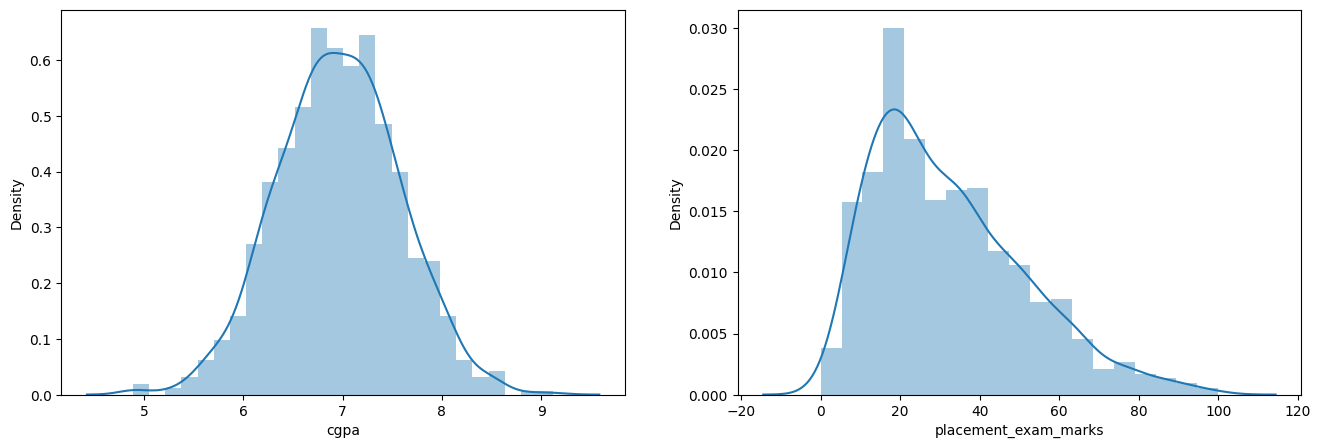

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [8]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [9]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [6]:
print('Mean Value of cgpa' , df['cgpa'].mean())
print('Std Value of cgpa' , df['cgpa'].std())
print('Max Value of cgpa' , df['cgpa'].max())
print('Min Value of cgpa' , df['cgpa'].min())

Mean Value of cgpa 6.96124
Std Value of cgpa 0.6158978751323896
Max Value of cgpa 9.12
Min Value of cgpa 4.89


In [10]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

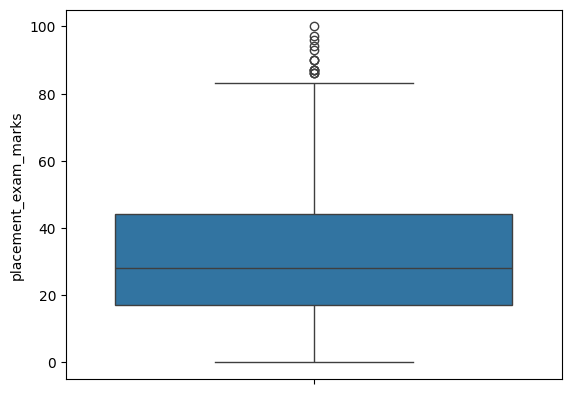

In [ ]:
sns.boxplot(df['placement_exam_marks'] )

In [12]:
#Finding IQR 
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [13]:
percentile25

np.float64(17.0)

In [14]:
percentile75

np.float64(44.0)

In [15]:
IQR = percentile75 - percentile25

In [16]:
IQR

np.float64(27.0)

In [22]:
lower_limit = (percentile25 - IQR*1.5)

In [23]:
upper_limit = (percentile75 + IQR*1.5)

In [24]:
print("UPPER LIMIT: " , upper_limit)
print("LOWER LIMIT: " , lower_limit)


UPPER LIMIT:  84.5
LOWER LIMIT:  -23.5


# Finding Outliers

In [25]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [26]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


# Trimming

In [27]:
new_df = df[df['placement_exam_marks']<upper_limit]

In [28]:
new_df.shape

(985, 3)

In [29]:
new_df.sample(5)

,cgpa,placement_exam_marks,placed
92,6.48,63.0,0
191,6.63,8.0,0
110,6.96,31.0,0
552,6.40,24.0,0
71,6.13,20.0,1


C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\784422751.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\784422751.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks

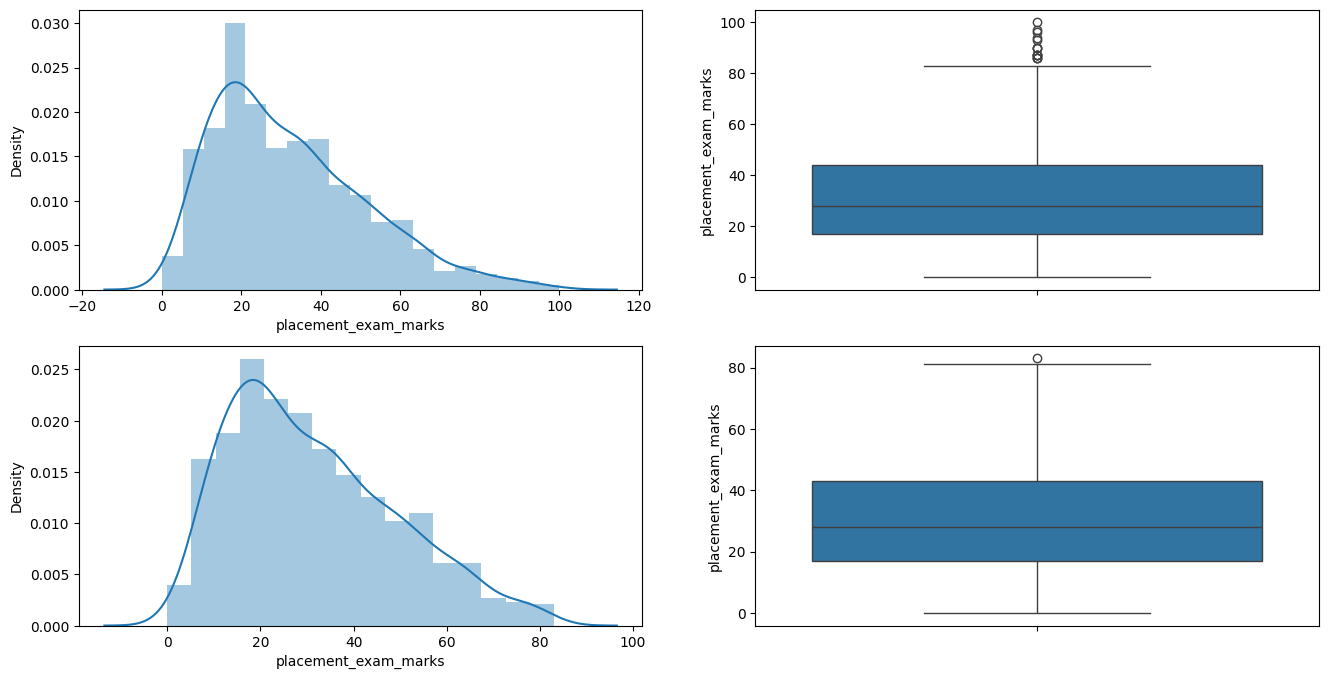

In [30]:
#Comparing
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])
plt.show()

In [31]:
new_df[new_df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed


# Capping

In [34]:
new_df_cap = df.copy()
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [35]:
new_df_cap[new_df_cap['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed


In [36]:
new_df_cap.sample(5)

,cgpa,placement_exam_marks,placed
185,7.30,31.0,0
301,7.84,5.0,1
651,6.57,39.0,1
948,6.38,15.0,0
587,7.58,14.0,1


C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\3900110175.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])
C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35520\3900110175.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam

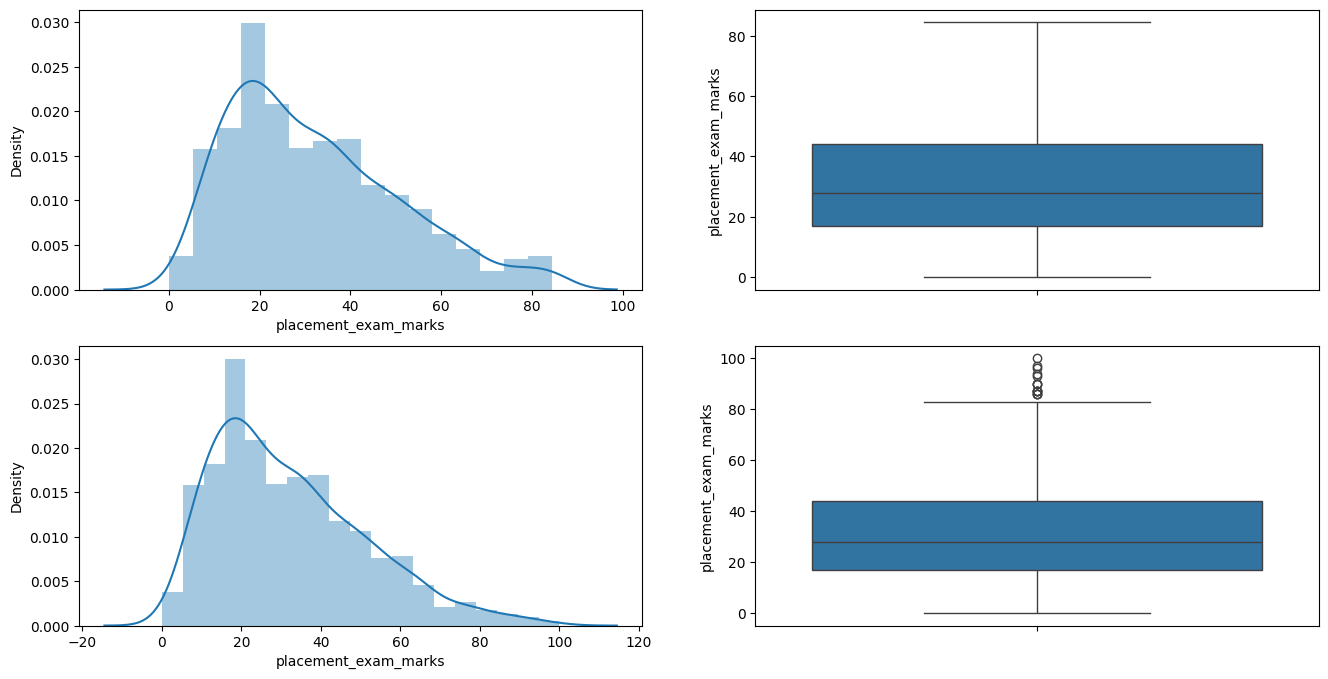

In [42]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(new_df_cap['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(new_df_cap['placement_exam_marks'])
plt.subplot(2,2,3)
sns.distplot(df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(df['placement_exam_marks'])
plt.show()

In [39]:
new_df_cap.shape

(1000, 3)